## Comparing growth rate dependency between two experiments

### Import package

In [13]:
import h5py
import numpy as np

from typing import cast, Dict
from pathlib import Path

from matplotlib import pyplot as plt

In [14]:
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "legend.fontsize": 12,
        "figure.titlesize": 18,
    }
)

### Load growth rate

In [15]:
input_dir: Path = Path("/work/b11209013/Kuang2008_v0.5.0/full")

# load NoRad growth rate
growthrate: Dict[str, np.ndarray] = {}

with h5py.File(input_dir / "NoRad/EigenAnalysis.h5", "r") as norad_ds:

    k: np.ndarray = cast(h5py.Dataset, norad_ds["k"])[...] # angular wavenumber

    growthrate["norad"] = cast(h5py.Dataset, norad_ds["GrowthRates"])[..., 0]

with h5py.File(input_dir / "CldRad/EigenAnalysis.h5", "r") as cldrad_ds:

    growthrate["cldrad"] = cast(h5py.Dataset, cldrad_ds["GrowthRates"])[..., 0]

### Identify most unstable mode

In [16]:
most_unstable: np.intp = np.argmax(growthrate["norad"])


### Positive modal growth rates

Show only finite growth rates greater than zero for the selected mode (`GrowthRates[..., 0]`). Masked values leave gaps in each curve. Growth rates use the original data units.


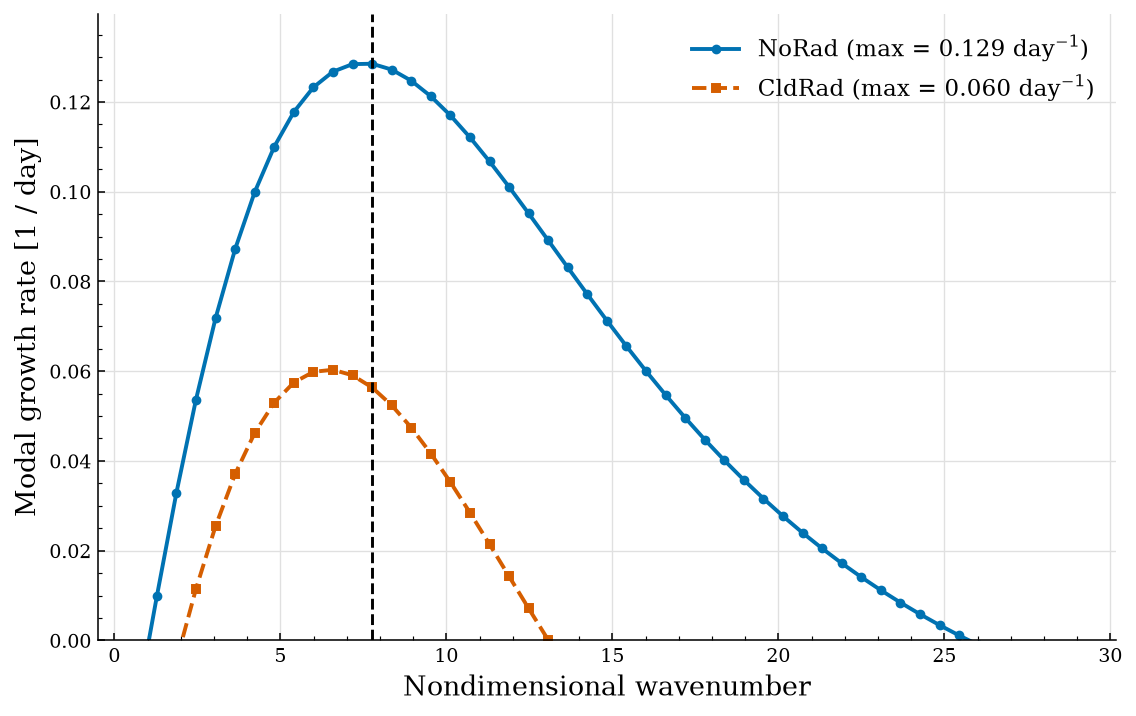

In [17]:
# Convert angular wavenumber using the existing nondimensionalization.
k_nondim: np.ndarray = 40000.0 * k / (2 * np.pi * 4320.0)

fig, ax = plt.subplots(figsize=(8, 5), dpi=140, layout="constrained")

styles = {
    "norad": {"label": "NoRad", "color": "#0072B2", "linestyle": "-", "marker": "o"},
    "cldrad": {"label": "CldRad", "color": "#D55E00", "linestyle": "--", "marker": "s"},
}
has_positive = False
for experiment, style in styles.items():
    rates = growthrate[experiment]
    valid = np.isfinite(k_nondim) & np.isfinite(rates)
    # Mask instead of removing points, so lines do not bridge nonpositive intervals.
    positive_rates = np.ma.masked_where(~valid, rates)
    has_positive = has_positive or bool(valid.any())
    finite_rates = rates[np.isfinite(rates)]
    max_text = f"{finite_rates.max():.3f} day$^{{-1}}$" if finite_rates.size else "N/A"
    legend_label = f"{style['label']} (max = {max_text})"
    ax.plot(k_nondim, positive_rates, linewidth=2, markersize=4,
            **{**style, "label": legend_label})
ax.axvline(k_nondim[most_unstable], color="k", linestyle="dashed")
ax.set(
    xlabel="Nondimensional wavenumber",
    ylabel="Modal growth rate [1 / day]",
)
ax.minorticks_on()
ax.tick_params(axis='both', which="both", direction='in') 
ax.set_ylim(bottom=0)
ax.margins(x=0.02)
ax.set_axisbelow(True)
ax.grid(True, color="0.88", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=10)
ax.legend(frameon=False)

plt.savefig("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/experiment_contrast/growthrate_contrast.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
